# Multi-Resolution Registration with ngff-zarr and ITKElastix

This notebook demonstrates a workflow that combines [ngff-zarr](https://github.com/fideus-labs/ngff-zarr) multi-resolution image pyramids with [ITKElastix](https://github.com/InsightSoftwareConsortium/ITKElastix) registration.

The approach:

1. Load two images and convert them to `ngff_zarr.Multiscales` pyramids with `to_multiscales`.
2. Register the images at a **coarse resolution** for speed (rigid → affine → B-spline).
3. Convert the Elastix result to a standard `itk.CompositeTransform`.
4. Apply the transform to resample the **full-resolution** image in parallel using `dask.array.map_blocks`, reading only the moving-image region the resample needs.

The `ngff_zarr` functions `itk_image_to_ngff_image` and `ngff_image_to_itk_image` bridge between ITK and ngff-zarr data representations, preserving spatial metadata (spacing, origin).

In [1]:
import functools

import itk
import numpy as np
import dask.array as da
import matplotlib.pyplot as plt
from ngff_zarr import (
    itk_image_to_ngff_image,
    ngff_image_to_itk_image,
    resample_bounding_box,
    to_multiscales,
    to_ngff_image,
)

%matplotlib inline


## Load Images

We load the fixed and moving 2D CT head slices as ITK float images, matching
Elastix's default internal pixel type.


In [2]:
fixed_image = itk.imread("data/CT_2D_head_fixed.mha", itk.F)
moving_image = itk.imread("data/CT_2D_head_moving.mha", itk.F)

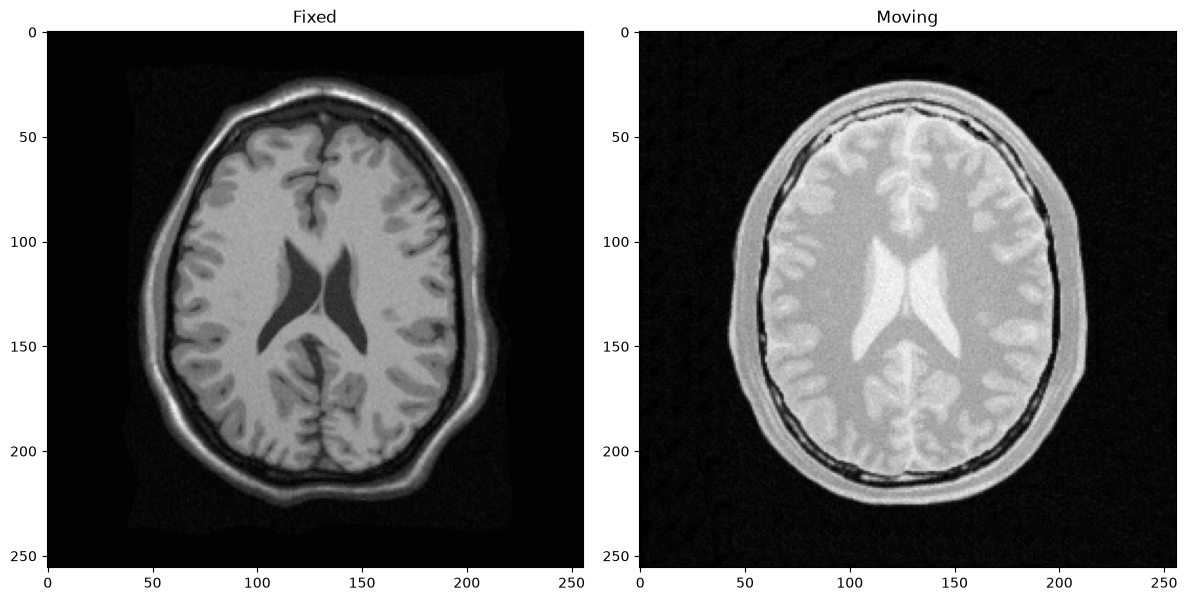

In [3]:
fig, axs = plt.subplots(1, 2, figsize=[12, 6])
axs[0].imshow(fixed_image, cmap="gray")
axs[0].set_title("Fixed")
axs[1].imshow(moving_image, cmap="gray")
axs[1].set_title("Moving")
plt.tight_layout()
plt.show()

## Generate Multi-Resolution Pyramids with ngff-zarr

`itk_image_to_ngff_image` converts an `itk.Image` to an `NgffImage`, preserving spacing and origin as `scale` and `translation` metadata. The image data is backed by a dask array.

`to_multiscales` then generates a multi-resolution pyramid. Here we use `scale_factors=[2, 4]`, which produces three levels: the original resolution, 2× downsampled, and 4× downsampled. We will register at the coarsest level for speed.

For registration alone a single factor, `scale_factors=[4]`, would be enough; the intermediate level is what a stored OME-Zarr pyramid typically carries for visualization, and this example builds the same kind of pyramid.

In [4]:
ngff_fixed_image = itk_image_to_ngff_image(fixed_image)
ngff_moving_image = itk_image_to_ngff_image(moving_image)

scale_factors = [2, 4]
multiscales_fixed = to_multiscales(ngff_fixed_image, scale_factors=scale_factors)
multiscales_moving = to_multiscales(ngff_moving_image, scale_factors=scale_factors)

print("Fixed image pyramid:")
for i, image in enumerate(multiscales_fixed.images):
    print(f"  Level {i}: shape={image.data.shape}, scale={image.scale}")

print("\nMoving image pyramid:")
for i, image in enumerate(multiscales_moving.images):
    print(f"  Level {i}: shape={image.data.shape}, scale={image.scale}")

Fixed image pyramid:
  Level 0: shape=(256, 256), scale={'y': 1.0, 'x': 1.0}
  Level 1: shape=(128, 128), scale={'y': 2.0, 'x': 2.0}
  Level 2: shape=(64, 64), scale={'y': 4.0, 'x': 4.0}

Moving image pyramid:
  Level 0: shape=(256, 256), scale={'y': 1.0, 'x': 1.0}
  Level 1: shape=(128, 128), scale={'y': 2.0, 'x': 2.0}
  Level 2: shape=(64, 64), scale={'y': 4.0, 'x': 4.0}


## Register at Coarse Resolution

We extract the coarsest resolution level from both pyramids and convert back to `itk.Image` using `ngff_image_to_itk_image`. We pass `wasm=False` to get native `itk.Image` objects (rather than `itkwasm.image.Image` objects), which are required by ITKElastix.

We then run a three-stage Elastix registration (rigid → affine → B-spline). Registering at lower resolution is significantly faster. Because the resulting transform is defined in physical coordinates, it can be applied at any resolution level.

In [5]:
# Extract the coarsest resolution level
fixed_coarse_ngff_image = multiscales_fixed.images[-1]
moving_coarse_ngff_image = multiscales_moving.images[-1]

print(f"Coarse fixed:  shape={fixed_coarse_ngff_image.data.shape}, scale={fixed_coarse_ngff_image.scale}")
print(f"Coarse moving: shape={moving_coarse_ngff_image.data.shape}, scale={moving_coarse_ngff_image.scale}")

Coarse fixed:  shape=(64, 64), scale={'y': 4.0, 'x': 4.0}
Coarse moving: shape=(64, 64), scale={'y': 4.0, 'x': 4.0}


In [6]:
# Convert the coarse NgffImage objects back to itk.Image for Elastix.
# The CT data is float32, so these are already itk.Image[itk.F, 2].
fixed_coarse_image = ngff_image_to_itk_image(fixed_coarse_ngff_image, wasm=False)
moving_coarse_image = ngff_image_to_itk_image(moving_coarse_ngff_image, wasm=False)


In [7]:
# Set up multi-stage registration: rigid -> affine -> bspline
parameter_object = itk.ParameterObject.New()
parameter_object.AddParameterMap(
    itk.ParameterObject.GetDefaultParameterMap("rigid")
)
parameter_object.AddParameterMap(
    itk.ParameterObject.GetDefaultParameterMap("affine")
)
parameter_object.AddParameterMap(
    itk.ParameterObject.GetDefaultParameterMap("bspline")
)

In [8]:
# Run registration using the object-oriented API.
# We need the registration_method object to later extract the ITK transform.
registration_method = itk.ElastixRegistrationMethod[
    type(fixed_coarse_image), type(moving_coarse_image)
].New(
    fixed_image=fixed_coarse_image,
    moving_image=moving_coarse_image,
    parameter_object=parameter_object,
)
registration_method.SetLogToConsole(False)
registration_method.Update()

result_image_coarse = registration_method.GetOutput()

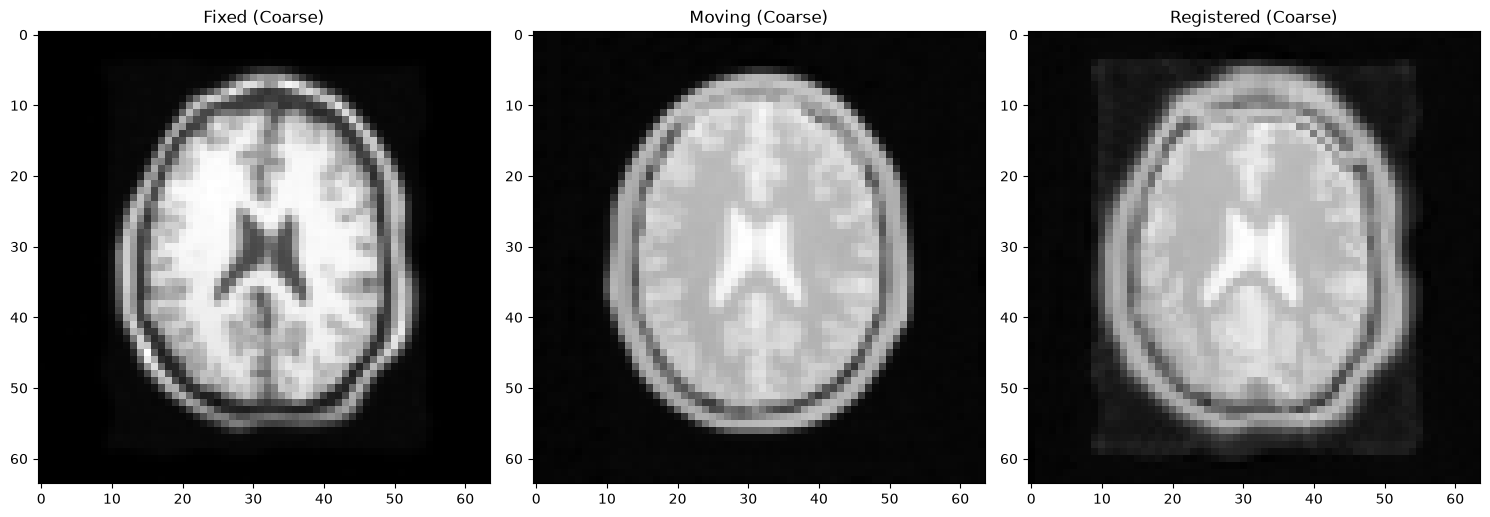

In [9]:
# Visualize the coarse registration result
fig, axs = plt.subplots(1, 3, figsize=[15, 5])
axs[0].imshow(fixed_coarse_image, cmap="gray")
axs[0].set_title("Fixed (Coarse)")
axs[1].imshow(moving_coarse_image, cmap="gray")
axs[1].set_title("Moving (Coarse)")
axs[2].imshow(result_image_coarse, cmap="gray")
axs[2].set_title("Registered (Coarse)")
plt.tight_layout()
plt.show()

## Convert to ITK Transform

The `ConvertToItkTransform` method converts the Elastix registration results into a standard `itk.CompositeTransform`. This composite transform chains the rigid, affine, and B-spline stages into a single object that can be used with any ITK resampling filter.

Because the transform is defined in **physical coordinates** (not pixel indices), it applies correctly at any resolution level.

In [10]:
elx_advanced_transform = registration_method.GetCombinationTransform()
# ConvertToItkTransform hands back the itk.Transform[itk.D, 2, 2] base, so the
# cast is what exposes the composite interface. elastix's newer
# ConvertCompositionToItkTransform (SuperElastix/elastix#1464) returns the
# itk.CompositeTransform directly; once ITKElastix ships it, the cast goes away.
itk_composite_transform = itk.CompositeTransform[itk.D, 2].cast(
    registration_method.ConvertToItkTransform(elx_advanced_transform)
)
print(itk_composite_transform)

CompositeTransform (0x3e70ce10)
  RTTI typeinfo:   itk::CompositeTransform<double, 2u>
  Reference Count: 1
  Modified Time: 117107
  Debug: Off
  Object Name: 
  Observers: 
    none
  TransformQueue: 
  >>>>>>>>>
  BSplineTransform (0x38ff91c0)
    RTTI typeinfo:   itk::BSplineTransform<double, 2u, 3u>
    Reference Count: 1
    Modified Time: 117094
    Debug: Off
    Object Name: 
    Observers: 
      none
    CoefficientImage: [ 0x3919a890, 0x3ecba3a0 ]
    TransformDomainOrigin: [-5.60857, -4.69613]
    TransformDomainPhysicalDimensions: [264.21, 263.665]
    TransformDomainDirection: 1 0
0 1

    TransformDomainMeshSize: [26, 26]
    GridSize: [29, 29]
    GridOrigin: [-15.7705, -14.8371]
    GridSpacing: [10.1619, 10.1409]
    GridDirection: 1 0
0 1

  >>>>>>>>>
  AffineTransform (0x38f1d080)
    RTTI typeinfo:   itk::AffineTransform<double, 2u>
    Reference Count: 1
    Modified Time: 117100
    Debug: Off
    Object Name: 
    Observers: 
      none
    Matrix: 
      1.003

## Apply the Transform at Full Resolution with dask.array.map_blocks

The transform found at coarse resolution now resamples the **full-resolution**
moving image. `dask.array.map_blocks` processes each chunk of the output
independently and in parallel. For every block, `resample_block`:

- turns the block's array location into a grid in physical space, using the
  fixed image's spacing and origin;
- asks `resample_bounding_box` -- from geometry alone, without reading
  any pixels -- which region of the moving image this block's resample
  will read;
- materializes only that region as an ITK image and resamples it into the
  block's reference grid.

The full moving image is never loaded in memory: each block reads just its
own region. On this small 2D image the saving is modest; on a large,
chunked, or remote OME-Zarr store each region is a small fraction of the
image, which is what keeps the workflow out of core.

`itk.resample_image_filter` is already multi-threaded within one process.
What `map_blocks` adds is scale: each block needs only its own region of the
moving image and its own small output allocation, so the output can exceed
memory and the blocks can run across the workers of a Dask cluster.


In [11]:
# Get the full-resolution images (dask-backed)
fixed_full = multiscales_fixed.images[0]
moving_full = multiscales_moving.images[0]

print(f"Full-resolution fixed:  shape={fixed_full.data.shape}")
print(f"Full-resolution moving: shape={moving_full.data.shape}")


Full-resolution fixed:  shape=(256, 256)
Full-resolution moving: shape=(256, 256)


In [12]:
def resample_block(
    block,
    *,
    block_info,
    transform,
    fixed_image,
    moving_image,
):
    """Resample one output block of the fixed grid from the moving image.

    dask.array.map_blocks calls this once per chunk of the output grid, in
    parallel. Each call transforms one block independently of the others:

    1. block_info carries the block's location within the whole output
       array; with the fixed image's scale and translation it describes
       the block's grid in physical space.
    2. resample_bounding_box computes, from that geometry alone, the
       region of the moving image this block's resample reads.
    3. The moving image is cropped to that region, and only the crop is
       materialized as an ITK image -- the full moving image is never
       loaded in memory.
    4. itk.resample_image_filter maps each pixel of the block's reference
       grid through the registration transform and interpolates the
       cropped moving image at the mapped point.
    5. The resampled pixels come back as a NumPy array; dask assembles the
       blocks into the final full-resolution result.
    """

    # Step 1: the block's grid in physical space.
    # block_info is keyed by the position of each array passed to map_blocks;
    # fixed_grid is the only one, so block_info[0] describes this block of it.
    # Its "array-location" is [(y_start, y_stop), (x_start, x_stop)]: the
    # block's index range along each dim of the fixed image, in (y, x) order.
    array_location = block_info[0]["array-location"]
    dims = fixed_image.dims
    block_translation = {
        dim: fixed_image.translation[dim] + start * fixed_image.scale[dim]
        for dim, (start, _stop) in zip(dims, array_location)
    }
    block_grid = to_ngff_image(
        np.zeros(block.shape, dtype=np.uint8),
        dims=dims,
        scale=fixed_image.scale,
        translation=block_translation,
    )

    # Step 2: the moving-image region this block's resample reads.
    region = resample_bounding_box(transform, block_grid, moving_image)

    # Step 3: materialize only that region. A block that falls entirely
    # outside the moving image samples nothing.
    moving_block = region.crop(moving_image)
    if moving_block is None:
        return np.zeros(block.shape, dtype=np.float32)
    moving_itk = ngff_image_to_itk_image(moving_block, wasm=False)

    # Step 4: resample into the block's reference grid.
    reference = itk.Image[itk.F, 2].New()
    itk_region = itk.ImageRegion[2]()
    itk_region.SetSize([int(block.shape[1]), int(block.shape[0])])  # ITK size is [x, y]
    reference.SetRegions(itk_region)
    reference.SetSpacing([fixed_image.scale["x"], fixed_image.scale["y"]])
    reference.SetOrigin([block_translation["x"], block_translation["y"]])
    reference.Allocate()

    resampled = itk.resample_image_filter(
        moving_itk,
        transform=transform,
        use_reference_image=True,
        reference_image=reference,
    )

    # Step 5: hand the block back to dask as a NumPy array.
    return itk.array_from_image(resampled)


In [13]:
# This small image fits in a single dask chunk, which would give map_blocks
# only one block to work on. Re-chunk the output grid so the resampling
# actually runs as parallel blocks; large images arrive already chunked and
# skip this step.
fixed_grid = fixed_full.data.rechunk(64)

# The images travel to the block function through functools.partial: they
# are geometry inputs, not arrays for map_blocks to align and map over.
resample_full = functools.partial(
    resample_block,
    transform=itk_composite_transform,
    fixed_image=fixed_full,
    moving_image=moving_full,
)

# Apply the transform in parallel across all chunks
resampled_dask_array = da.map_blocks(resample_full, fixed_grid, dtype=np.float32)

print(f"Resampled dask array: shape={resampled_dask_array.shape}, chunks={resampled_dask_array.chunks}")
print(f"Blocks resampled in parallel: {resampled_dask_array.numblocks[0] * resampled_dask_array.numblocks[1]}")


Resampled dask array: shape=(256, 256), chunks=((64, 64, 64, 64), (64, 64, 64, 64))
Blocks resampled in parallel: 16


## Visualize the Resampling Regions

Each output block reads its own region of the moving image, and
`resample_bounding_box` can compute that region for any sub-grid of the
fixed image. Three views make the geometry concrete:

1. one fixed block and the moving-image region its resample reads;
2. the same block with different `padding` values -- the region grows to
   cover wider interpolation kernels;
3. every block of the block-wise resample, with its corresponding
   moving-image region in the same color.


In [14]:
import matplotlib.patches as mpatches

fixed_array = np.asarray(fixed_full.data)
moving_array = np.asarray(moving_full.data)


def block_bounding_box(array_location, padding=1):
    """The moving-image region one output block's resample reads.

    array_location is [(y_start, y_stop), (x_start, x_stop)] in the fixed
    grid, as dask's block_info reports it. A geometry-only NgffImage stands
    in for the block: same scale as the fixed image, translation shifted to
    the block's origin. No pixels are read.
    """
    block_shape = tuple(stop - start for start, stop in array_location)
    block_translation = {
        dim: fixed_full.translation[dim] + array_location[i][0] * fixed_full.scale[dim]
        for i, dim in enumerate(fixed_full.dims)
    }
    block_grid = to_ngff_image(
        np.zeros(block_shape, dtype=np.uint8),
        dims=fixed_full.dims,
        scale=fixed_full.scale,
        translation=block_translation,
    )
    return resample_bounding_box(
        itk_composite_transform, block_grid, moving_full, padding=padding
    )


def draw_box(ax, start, size, color, label=None, linewidth=2):
    """Outline a region given per-dimension start/size in index space."""
    ax.add_patch(
        mpatches.Rectangle(
            (start["x"] - 0.5, start["y"] - 0.5),
            size["x"],
            size["y"],
            edgecolor=color,
            facecolor="none",
            linewidth=linewidth,
            label=label,
        )
    )


def block_locations(dask_array):
    """[(y_start, y_stop), (x_start, x_stop)] for every block of the array."""
    offsets = [np.concatenate([[0], np.cumsum(sizes)]) for sizes in dask_array.chunks]
    return [
        [
            (int(offsets[0][row]), int(offsets[0][row + 1])),
            (int(offsets[1][col]), int(offsets[1][col + 1])),
        ]
        for row in range(len(dask_array.chunks[0]))
        for col in range(len(dask_array.chunks[1]))
    ]


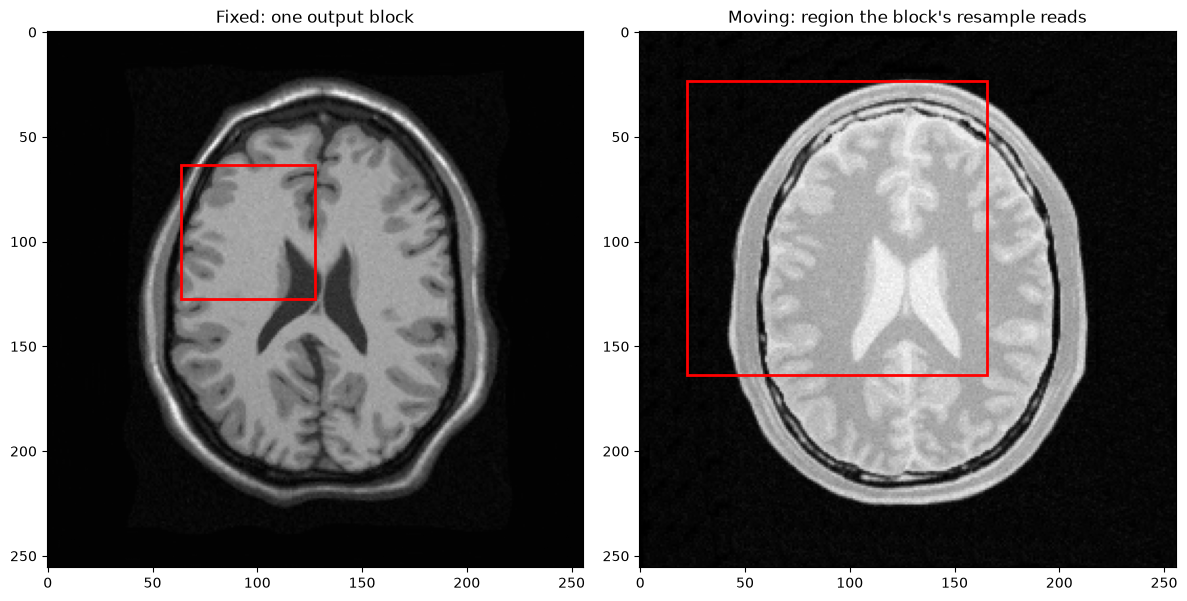

In [15]:
# 1. One fixed block and the moving-image region its resample reads.
locations = block_locations(fixed_grid)
location = locations[5]  # an interior block

region = block_bounding_box(location)

fig, axs = plt.subplots(1, 2, figsize=[12, 6])
axs[0].imshow(fixed_array, cmap="gray")
draw_box(
    axs[0],
    {"y": location[0][0], "x": location[1][0]},
    {"y": location[0][1] - location[0][0], "x": location[1][1] - location[1][0]},
    "red",
)
axs[0].set_title("Fixed: one output block")
axs[1].imshow(moving_array, cmap="gray")
draw_box(axs[1], region.start_index, region.size, "red")
axs[1].set_title("Moving: region the block's resample reads")
plt.tight_layout()
plt.show()


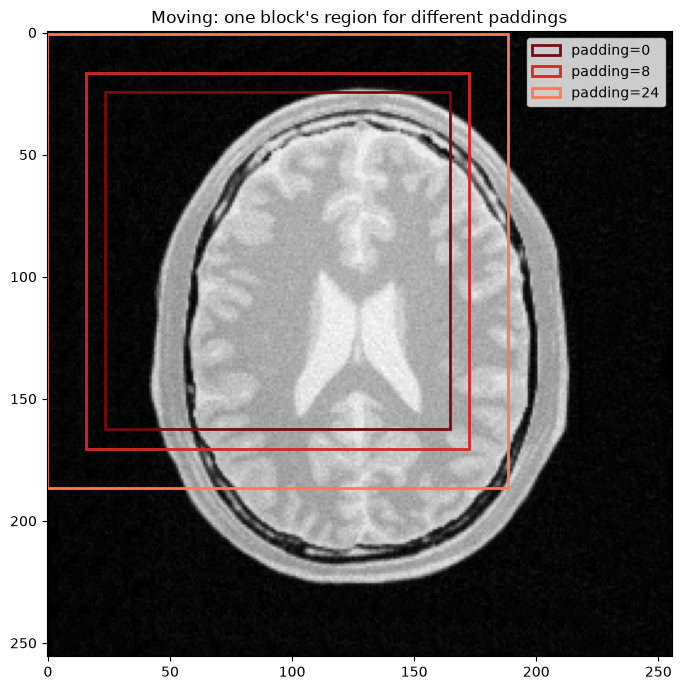

In [16]:
# 2. The same block with growing padding: wider interpolation kernels
# read further, so the region expands. Same color, lighter shades.
paddings = [0, 8, 24]
shades = plt.cm.Reds(np.linspace(0.95, 0.45, len(paddings)))

fig, ax = plt.subplots(figsize=[7, 7])
ax.imshow(moving_array, cmap="gray")
for pad, shade in zip(paddings, shades):
    padded = block_bounding_box(location, padding=pad)
    draw_box(ax, padded.start_index, padded.size, shade, label=f"padding={pad}")
ax.set_title("Moving: one block's region for different paddings")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


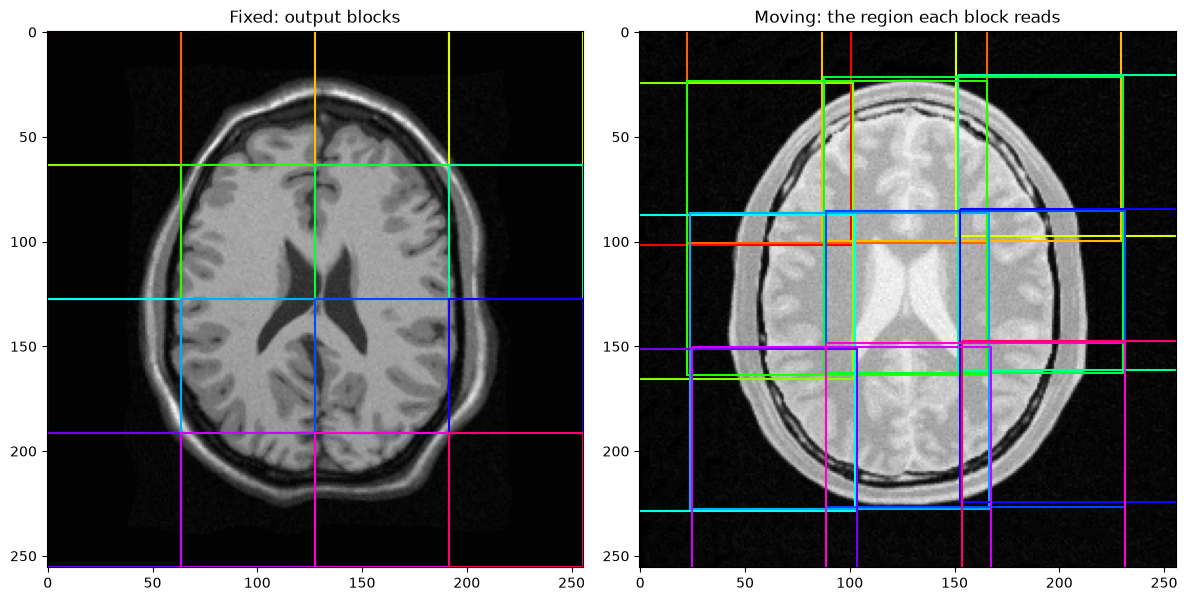

In [17]:
# 3. Every block of the block-wise resample and its moving-image region,
# one color per block. Each region follows its block through the
# registration transform, and neighboring regions overlap.
colors = plt.cm.hsv(np.linspace(0, 1, len(locations), endpoint=False))

fig, axs = plt.subplots(1, 2, figsize=[12, 6])
axs[0].imshow(fixed_array, cmap="gray")
axs[1].imshow(moving_array, cmap="gray")
for location, color in zip(locations, colors):
    draw_box(
        axs[0],
        {"y": location[0][0], "x": location[1][0]},
        {"y": location[0][1] - location[0][0], "x": location[1][1] - location[1][0]},
        color,
        linewidth=1.5,
    )
    region = block_bounding_box(location)
    draw_box(axs[1], region.start_index, region.size, color, linewidth=1.5)
axs[0].set_title("Fixed: output blocks")
axs[1].set_title("Moving: the region each block reads")
plt.tight_layout()
plt.show()


In [18]:
# Compute the result (triggers parallel execution across chunks)
resampled_array = resampled_dask_array.compute()
print(f"Resampled result shape: {resampled_array.shape}")

Resampled result shape: (256, 256)


## Visualize Results

Compare the full-resolution resampled result with the fixed and moving images.

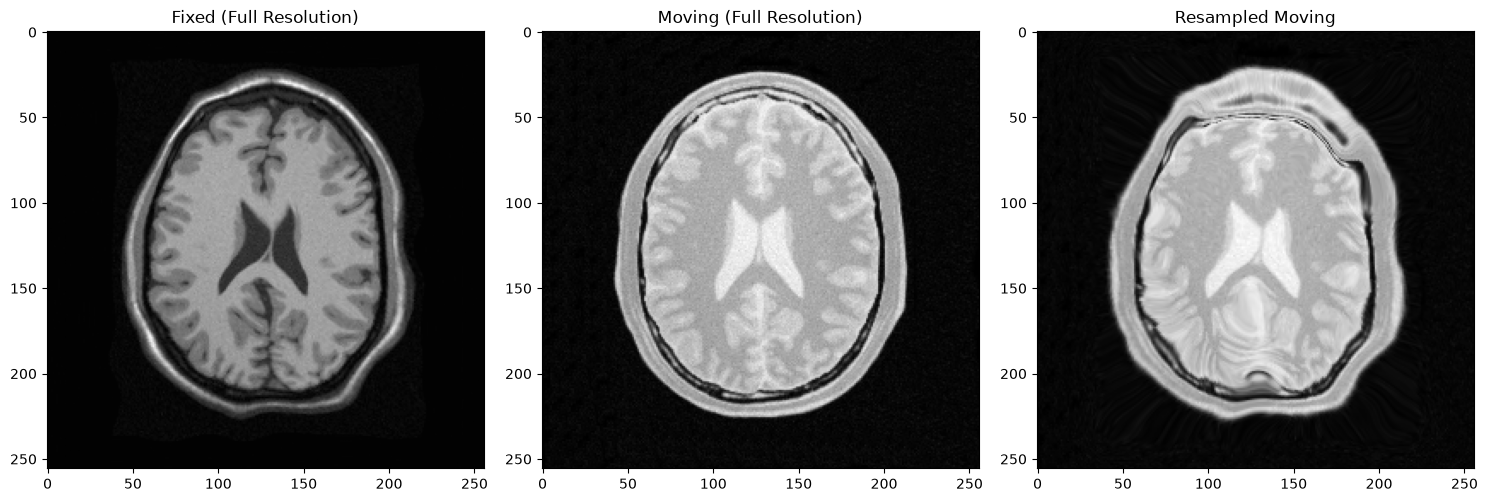

In [19]:
fig, axs = plt.subplots(1, 3, figsize=[15, 5])
axs[0].imshow(fixed_array, cmap="gray")
axs[0].set_title("Fixed (Full Resolution)")
axs[1].imshow(np.asarray(moving_full.data), cmap="gray")
axs[1].set_title("Moving (Full Resolution)")
axs[2].imshow(resampled_array, cmap="gray")
axs[2].set_title("Resampled Moving")
plt.tight_layout()
plt.show()

## The Same Resample in One Call

`ngff_zarr.resample` is the loop above as a library call. It computes each
block's region with the same `resample_bounding_box`, then builds the blocks
as tasks of a single Dask graph that reference the moving chunks directly, so
a chunk several blocks read is decoded once instead of re-cropped per block.
It also carries the padding each interpolator needs and the value to write
where a block samples outside the moving image.

The loop above is what happens per block. This is what a pipeline calls.

In [20]:
from dataclasses import replace

from ngff_zarr import resample

# resample lays its output blocks on the chunks of the fixed image, so passing
# the rechunked grid gives it the same blocks the loop above worked on.
resampled_ngff_image = resample(
    itk_composite_transform, replace(fixed_full, data=fixed_grid), moving_full
)

# Still lazy: nothing is read until the Dask array is.
print(f"shape={resampled_ngff_image.data.shape}, chunks={resampled_ngff_image.data.chunks}")

largest_difference = np.abs(np.asarray(resampled_ngff_image.data) - resampled_array).max()
print(f"Largest difference from the block loop: {largest_difference}")

shape=(256, 256), chunks=((64, 64, 64, 64), (64, 64, 64, 64))
Largest difference from the block loop: 0.0


## Summary

This example demonstrated a multi-resolution registration and resampling workflow:

- **`ngff_zarr.itk_image_to_ngff_image`** and **`ngff_zarr.ngff_image_to_itk_image`** bridge between ITK and ngff-zarr data representations, preserving spatial metadata.
- **`ngff_zarr.to_multiscales`** generates multi-resolution pyramids from a single image with one call.
- **Coarse-resolution registration** with ITKElastix (rigid → affine → B-spline) is fast, and because the resulting transform is defined in physical coordinates, it applies at any resolution.
- **`ngff_zarr.resample_bounding_box`** computes, from geometry alone, the moving-image region a resample will read, so only those chunks are materialized.
- **`dask.array.map_blocks`** enables parallel resampling at full resolution, processing each output chunk independently with `itk.resample_image_filter`.
- **`ngff_zarr.resample`** packages the same block-wise resample as one call.
